# Human SAN — Spontaneous Spiking with the Rush-Larsen Integrator

This notebook demonstrates the Rush-Larsen integrator on the
Fabbri-Fantini-Wilders-Severi 2017 human sinoatrial-node (SAN) model.

The SAN model contains 17 Hodgkin-Huxley-style gating variables, each obeying the following dynamic:

$$\frac{dy}{dt} = \frac{y_\infty(V) - y}{\tau(V)}$$

Some time constants $\tau$ fall below 0.1 ms (e.g. $\tau_{m}$, $\tau_{\mathrm{fCa}}$),
making the gating very stiff. 
Specifically, explicit methods require $\Delta t \ll \tau_{\min}$ for stability in many sharp transition points in the dynamics.
Implicit solvers can handle this, but still carry large overheads due to Newton iterations for non-linear solves.

For the relaxation form above, the exact solution over a step $\Delta t$
(assuming locally constant $y_\infty$ and $\tau$) can be written in a closed form:

$$y(t + \Delta t) = y_\infty + (y(t) - y_\infty)\, e^{-\Delta t / \tau}$$

which is stable regardless of $\Delta t$

Thus, we can implement a naive Euler-like step solver for the ODE.
However, we replace each gating dynamic with the exact step update above.
This leaves the other states to update using a Euler step, but we assume that their dynamics are not stiff.

To do this, we build a custom solver that directly computes the updates.
However, we cannot simply pass a rhs() -> dxdt update to it, we need to jointly design the solver and rate update.
So we are out of luck with standard ODE solvers.

Instead of generating a rhs(), we generate a stepper() -> x_new update, which we can inject into the solver and bypass their standard routines.
The difference is that the stepper also receives the time step dt.
The pattern is something like: model -> stepper_fn; ODEsolver(RLsolver(stepper_fn())) -> output


In [1]:
import pathlib
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

from cellml2py import (
    CompileOptions,
    OverrideSpec,
    RushLarsenSolver,
    compile_cellml,
    simulate_rush_larsen,
)

MODEL_PATH = (
    pathlib.Path("../") / "data" / "HumanSAN_Fabbri_Fantini_Wilders_Severi_2017.cellml"
)

DT = 1e-5  # s = 0.01 ms
T_END = 1.0  # s  ≈ 1 pacemaker cycle at rest (~1 s/beat)


## Compile RL gate detection

The compiler scans every rate equation for the pattern
$\bigl(y_\infty - y\bigr) / \tau$ (and the `SAFE_DIVIDE` equivalent).
Detected gates are stored in `model.layout` and a compiled stepper becomes
available via `model.make_stepper()`.

In [2]:
model = compile_cellml(MODEL_PATH, backend="numpy")

n_states = model.initial_state.size
has_stepper = model._stepper_builder is not None

print(f"state variables: {n_states}")
print(f"stepper available: {has_stepper}")
print()

# check which gates are detected as Rush-Larsen type
from cellml2py.cellml_compiler import _CellMLModelCompiler

_compiler = _CellMLModelCompiler(MODEL_PATH, CompileOptions())
_compiler.compile()

print(f"Rush-Larsen gates detected: {len(_compiler.rush_larsen_gates)}")
for root, (yinf, tau) in _compiler.rush_larsen_gates.items():
    short = root.split("::", 1)[-1]
    print(f"  {short:<12}  y_inf = {yinf[:55]}")

state variables: 33
stepper available: True

Rush-Larsen gates detected: 17
  y             y_inf = V("i_f_y_gate::y_infinity")
  m             y_inf = V("i_Na_m_gate::m_infinity")
  h             y_inf = V("i_Na_h_gate::h_infinity")
  dL            y_inf = V("i_CaL_dL_gate::dL_infinity")
  fL            y_inf = V("i_CaL_fL_gate::fL_infinity")
  fCa           y_inf = V("i_CaL_fCa_gate::fCa_infinity")
  dT            y_inf = V("i_CaT_dT_gate::dT_infinity")
  fT            y_inf = V("i_CaT_fT_gate::fT_infinity")
  r_Kur         y_inf = V("i_Kur_rKur_gate::r_Kur_infinity")
  s_Kur         y_inf = V("i_Kur_sKur_gate::s_Kur_infinity")
  q             y_inf = V("i_to_q_gate::q_infinity")
  r             y_inf = V("i_to_r_gate::r_infinity")
  paS           y_inf = V("i_Kr_pa_gate::pa_infinity")
  paF           y_inf = V("i_Kr_pa_gate::pa_infinity")
  piy           y_inf = V("i_Kr_pi_gate::pi_infinity")
  n             y_inf = V("i_Ks_n_gate::n_infinity")
  a             y_inf = V("i_KACh_a_ga

## NumPy

Numpy should work, but will be very slow: 
a 100 ms run at dt = 0.01 ms is approximately 170 evals times 10000 steps, which
takes ~30–40 s on a typical laptop.

In [3]:
model = compile_cellml(MODEL_PATH, backend="numpy")
stepper = model.make_stepper()
x0 = model.initial_state.copy()

# Short NumPy run: 100 ms → 10 000 steps at dt = 0.01 ms.
# Expected wall-clock time: ~30–40 s.
T_DEMO = 0.1

t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ts_np, ys_np = simulate_rush_larsen(model, (0.0, T_DEMO), dt=DT)
elapsed_np = time.perf_counter() - t0

n_steps_np = ts_np.size - 1
print(
    f"steps   : {n_steps_np:,}   elapsed: {elapsed_np:.1f} s ({elapsed_np / n_steps_np * 1e3:.2f} ms/step)"
)
print(f"finite  : {np.all(np.isfinite(ys_np))}")
print(f"V range : {ys_np[:, 0].min():.2f} to {ys_np[:, 0].max():.2f} mV")

steps   : 10,000   elapsed: 41.2 s (4.12 ms/step)
finite  : True
V range : -47.79 to -45.27 mV


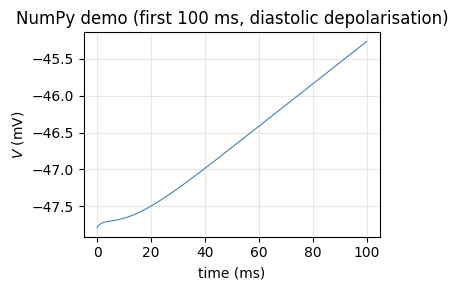

In [4]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_np * 1e3, ys_np[:, 0], lw=0.8, color="steelblue")
ax.set_xlabel("time (ms)")
ax.set_ylabel("$V$ (mV)")
ax.set_title(f"NumPy demo (first {int(T_DEMO * 1e3)} ms, diastolic depolarisation)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## JAX (manual stepping)

`simulate_rush_larsen(..., jit=True)` wraps steps in a `lax.scan` loop in a `jax.jit`.

`pip install cellml2py[jax]`

In [5]:
try:
    import jax
    import jax.numpy as jnp
    import diffrax

    print(f"JAX {jax.__version__}  |  diffrax {diffrax.__version__}")
    print(f"default backend: {jax.default_backend()}")
except ImportError:
    print("JAX / diffrax not installed — skipping sections 3–6.")
    print("Install with: pip install cellml2py[jax]")
    raise SystemExit(0)

JAX 0.10.0  |  diffrax 0.7.2
default backend: cpu


In [6]:
model_jax = compile_cellml(MODEL_PATH, backend="jax")
print(
    f"JAX model  states={model_jax.initial_state.size}  stepper={model_jax._stepper_builder is not None}"
)

JAX model  states=33  stepper=True


In [7]:
# Trigger compile
t0_wu = time.perf_counter()
_ = simulate_rush_larsen(model_jax, (0.0, 0.1), dt=DT, jit=True)
print(f"JIT warm-up (0.1 s): {time.perf_counter() - t0_wu:.1f} s")

# Full 1 s simulation
t0 = time.perf_counter()
ts_jax, ys_jax = simulate_rush_larsen(model_jax, (0.0, T_END), dt=DT, jit=True)
elapsed_jax = time.perf_counter() - t0

print(f"JAX RL (JIT)  steps={ts_jax.size - 1:,}   elapsed={elapsed_jax:.2f} s")

JIT warm-up (0.1 s): 1.8 s
JAX RL (JIT)  steps=100,000   elapsed=2.92 s


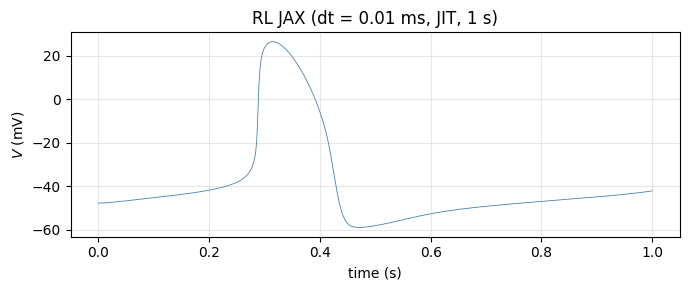

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.asarray(ts_jax), np.asarray(ys_jax[:, 0]), lw=0.6, color="steelblue")
ax.set_xlabel("time (s)")
ax.set_ylabel("$V$ (mV)")
ax.set_title(f"RL JAX (dt = {DT * 1e3:.2f} ms, JIT, {T_END:.0f} s)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## `RushLarsenSolver` for `diffrax.diffeqsolve`

`RushLarsenSolver` wraps the stepper using diffrax's `AbstractSolver`
interface. This gets all the extra benefits of diffrax.

However, we pass a rhs() Term to the solver. This is not used for the step updates!
No idea if this will raise unexpected bugs or lead to issues with adjoints, etc.

In [9]:
rhs = model_jax.make_rhs()
stepper_fn = model_jax.make_stepper()
solver = RushLarsenSolver(stepper_fn)

term = diffrax.ODETerm(lambda t, y, args: rhs(t, y, args))
ctrl = diffrax.ConstantStepSize()

_MAX_STEPS = int(T_END / DT) + 10


@jax.jit
def solve_dfx():
    y0 = jnp.array(model_jax.initial_state)
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=T_END,
        dt0=DT,
        y0=y0,
        stepsize_controller=ctrl,
        saveat=diffrax.SaveAt(ts=jnp.linspace(0.0, T_END, 4001)),
        max_steps=_MAX_STEPS,
    )
    return sol.ts, sol.ys


# Compile
t0_wu = time.perf_counter()
_ = solve_dfx()
print(f"RushLarsenSolver compile done  ({time.perf_counter() - t0_wu:.1f} s)")

t0 = time.perf_counter()
ts_dfx, ys_dfx = solve_dfx()
elapsed_dfx = time.perf_counter() - t0
print(f"diffrax elapsed: {elapsed_dfx:.2f} s   save-points: {ts_dfx.size}")


RushLarsenSolver compile done  (7.3 s)
diffrax elapsed: 1.30 s   save-points: 4001


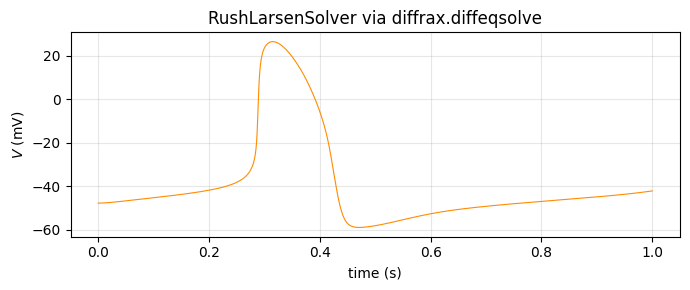

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.asarray(ts_dfx), np.asarray(ys_dfx[:, 0]), lw=0.8, color="darkorange")
ax.set_xlabel("time (s)")
ax.set_ylabel("$V$ (mV)")
ax.set_title("RushLarsenSolver via diffrax.diffeqsolve")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Forcing

`compile_cellml` accepts an `OverrideSpec(kind="rate_addend")` that appends an
external term to the chosen state's ODE right-hand side:

$$\frac{dV}{dt}\bigg|_{\text{forced}} = \frac{dV}{dt}\bigg|_{\text{intrinsic}} + I_{\text{ext}}(t)$$

`RushLarsenSolver` forwards `args` unchanged
to the stepper, which expects `args = (params, forcing_vector)`.


In [11]:
# V_ode is stored as "Membrane::V_ode"
V_IDX = next(
    i for i, n in enumerate(model_jax.layout.state_names) if n.endswith("::V_ode")
)
print(f"V_ode at state index {V_IDX}  ({model_jax.layout.state_names[V_IDX]})")

options_forced = CompileOptions(
    override_targets=(OverrideSpec(target="V_ode", kind="rate_addend"),),
    sanitize_nan=True,
)
model_forced = compile_cellml(MODEL_PATH, backend="jax", options=options_forced)
print(
    f"forced model: {len(model_forced.layout.state_names)} states  "
    f"forcing={model_forced.layout.forcing_names}  "
    f"stepper={model_forced._stepper_builder is not None}"
)

PEAK_RATE = 50.0  # mV/s — mild depolarising stimulus
RAMP_END = 1.0  # s — ramp saturates at the end of the simulation
forcing_jax = lambda t: jnp.where(t < RAMP_END, PEAK_RATE * t / RAMP_END, PEAK_RATE)


V_ode at state index 0  (Membrane::V_ode)
forced model: 33 states  forcing=('V_ode',)  stepper=True


In [12]:
rhs_forced_fn = model_forced.make_rhs()
step_forced_fn = model_forced.make_stepper()

# Wrap steppers with forcing as a simple example
def _stepper_f(t, y, dt, _args):
    fv = jnp.asarray(forcing_jax(t))
    return step_forced_fn(t, y, dt, (None, fv))

def _rhs_f(t, y, _args):
    fv = jnp.asarray(forcing_jax(t))
    return rhs_forced_fn(t, y, (None, fv))

solver_f = RushLarsenSolver(_stepper_f)
term_f = diffrax.ODETerm(_rhs_f)
_MAX_STEPS_F = int(T_END / DT) + 10

@jax.jit
def solve_dfx_forced():
    y0 = jnp.array(model_forced.initial_state)
    sol = diffrax.diffeqsolve(
        term_f,
        solver_f,
        t0=0.0,
        t1=T_END,
        dt0=DT,
        y0=y0,
        args=None,
        stepsize_controller=diffrax.ConstantStepSize(),
        saveat=diffrax.SaveAt(ts=jnp.linspace(0.0, T_END, 4001)),
        max_steps=_MAX_STEPS_F,
    )
    return sol.ts, sol.ys

# Compile
t0_wu = time.perf_counter()
_ = solve_dfx_forced()
print(f"forced diffrax compile: {time.perf_counter() - t0_wu:.1f} s")

t0 = time.perf_counter()
ts_dfx_f, ys_dfx_f = solve_dfx_forced()
elapsed_dfx_f = time.perf_counter() - t0
print(f"forced diffrax: {elapsed_dfx_f:.2f} s   save-points={ts_dfx_f.size}")


forced diffrax compile: 5.8 s
forced diffrax: 3.42 s   save-points=4001


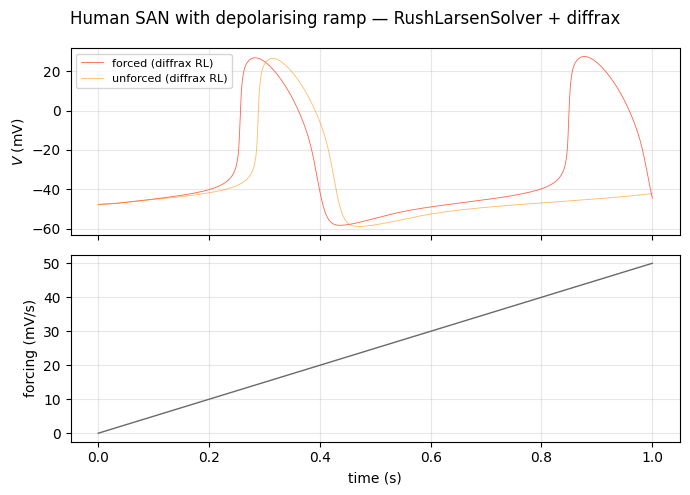

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axes[0].plot(
    np.asarray(ts_dfx_f),
    np.asarray(ys_dfx_f[:, V_IDX]),
    lw=0.6,
    color="tomato",
    label="forced (diffrax RL)",
)
axes[0].plot(
    np.asarray(ts_dfx),
    np.asarray(ys_dfx[:, V_IDX]),
    lw=0.6,
    color="darkorange",
    alpha=0.6,
    label="unforced (diffrax RL)",
)
axes[0].set_ylabel("$V$ (mV)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

forcing_vals = np.asarray(forcing_jax(jnp.asarray(np.asarray(ts_dfx_f))))
axes[1].plot(np.asarray(ts_dfx_f), forcing_vals, lw=1.0, color="dimgray")
axes[1].set_ylabel("forcing (mV/s)")
axes[1].set_xlabel("time (s)")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Human SAN with depolarising ramp — RushLarsenSolver + diffrax")
fig.tight_layout()
plt.show()


## JAX RL vs SciPy Radau


In [14]:
from scipy.integrate import solve_ivp

model_np = compile_cellml(MODEL_PATH, backend="numpy")
rhs_np = model_np.make_rhs()

t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sol_radau = solve_ivp(
        lambda t, y: rhs_np(t, y, None),
        (0.0, T_END),
        model_np.initial_state,
        method="Radau",
        max_step=0.01,  # s = 10 ms
        rtol=1e-6,
        atol=1e-8,
        dense_output=False,
    )
elapsed_radau = time.perf_counter() - t0
print(f"SciPy Radau   steps={sol_radau.t.size:,}   elapsed={elapsed_radau:.1f} s")
print(f"  success: {sol_radau.success}   message: {sol_radau.message}")

SciPy Radau   steps=362   elapsed=17.4 s
  success: True   message: The solver successfully reached the end of the integration interval.


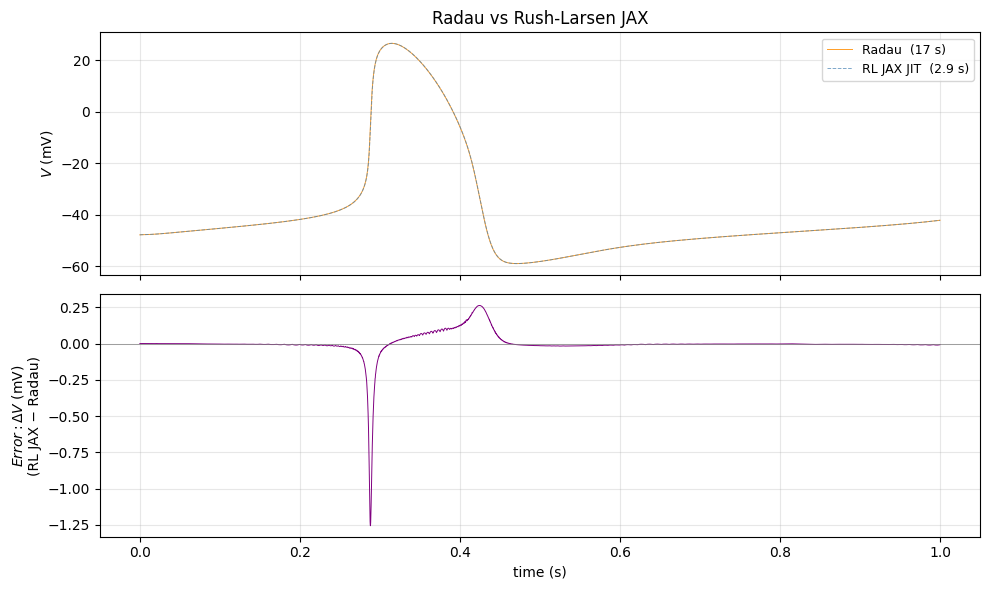

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(
    sol_radau.t,
    sol_radau.y[V_IDX],
    lw=0.7,
    color="darkorange",
    alpha=0.85,
    label=f"Radau  ({elapsed_radau:.0f} s)",
)
axes[0].plot(
    np.asarray(ts_jax),
    np.asarray(ys_jax[:, V_IDX]),
    lw=0.7,
    color="steelblue",
    linestyle="--",
    alpha=0.7,
    label=f"RL JAX JIT  ({elapsed_jax:.1f} s)",
)
axes[0].set_ylabel("$V$ (mV)")
axes[0].set_title("Radau vs Rush-Larsen JAX")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Difference panel (requires common time grid)
t_common = np.linspace(0.0, T_END, 4001)
v_radau_interp = np.interp(t_common, sol_radau.t, sol_radau.y[V_IDX])
v_jax_interp = np.interp(t_common, np.asarray(ts_jax), np.asarray(ys_jax[:, V_IDX]))
axes[1].plot(t_common, v_jax_interp - v_radau_interp, lw=0.7, color="purple")
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set_ylabel(r"$Error: \Delta V$ (mV)" + "\n(RL JAX \u2212 Radau)")
axes[1].set_xlabel("time (s)")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


In [17]:
print("=" * 50)
print("Timing 1 s simulation")
print("=" * 50)

print(f"  JAX RL (manual)  (JIT, 1 s) : {elapsed_jax:.2f} s")
print(f"  diffrax RL  (1 s)           : {elapsed_dfx:.2f} s")
print(f"  diffrax RL + forcing (1 s)  : {elapsed_dfx_f:.2f} s")
print(f"  SciPy Radau  (1 s)          : {elapsed_radau:.1f} s")

print(f"\n  Speed-up (JAX RL vs Radau)  : {elapsed_radau / elapsed_jax:.0f}x")


Timing 1 s simulation
  JAX RL (manual)  (JIT, 1 s) : 2.92 s
  diffrax RL  (1 s)           : 1.30 s
  diffrax RL + forcing (1 s)  : 3.42 s
  SciPy Radau  (1 s)          : 17.4 s

  Speed-up (JAX RL vs Radau)  : 6x
